**Regression Metrics for Linear Regression**
<br><br>
Metrics used in a LR model:<br>
1. MAE - Mean Absolute Error
2. MSE - Mean Squared Error
3. RMSE - Root Mean Squared Error
4. R2 score
5. Adjusted R2 score

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('placement.csv')
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


Text(0, 0.5, 'Package in LPA')

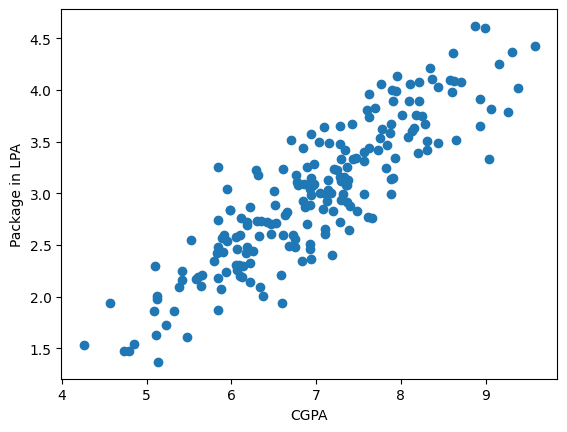

In [3]:
plt.scatter(df['cgpa'], df['package'])
plt.xlabel("CGPA")
plt.ylabel("Package in LPA")

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_absolute_error

In [ ]:
X = df.iloc[:,:1]
y = df.iloc[:,1]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [ ]:
lr = LinearRegression()

In [ ]:
lr.fit(X_train, y_train)

In [ ]:
plt.scatter(df['cgpa'], df['package'])
plt.plot(X_train, lr.predict(X_train), color='red')
plt.xlabel("CGPA")
plt.ylabel("Package in LPA")

In [ ]:
y_pred = lr.predict(X_test)

In [ ]:
y_test.values

In [ ]:
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("Root Mean Squared Error:", root_mean_squared_error(y_test, y_pred))




In [ ]:
print("r2 score:", r2_score(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

In [ ]:
#Adjusted R2 Score
adj_r2 = 1 - (((1 - r2)*(X_test.shape[0] - 1)) / (X_test.shape[0] - 1 - 1))
print("Adjusted r2 score:", adj_r2)

Now lets add a new column irrelevant to our data to see how it affects the r2 score and adjusted r2 score

In [5]:
new_df = df.copy()
new_df['irrelev_data'] = np.random.random(200)

new_df = new_df[['cgpa', 'irrelev_data', 'package']]
new_df.head()

,cgpa,irrelev_data,package
0,6.89,0.632096,3.26
1,5.12,0.321752,1.98
2,7.82,0.699216,3.25
3,7.42,0.599115,3.67
4,6.94,0.306006,3.57


Text(0, 0.5, 'Package in LPA')

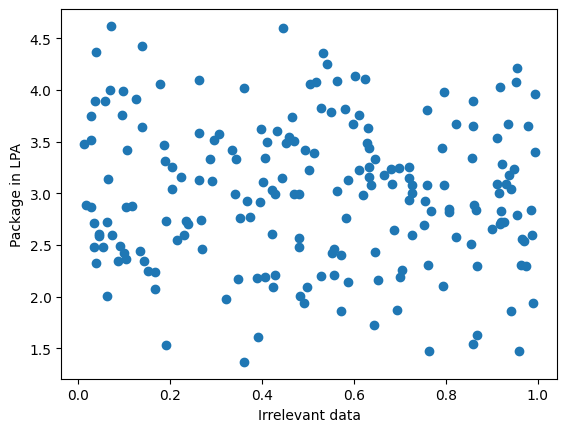

In [6]:
plt.scatter(new_df['irrelev_data'], new_df['package'])
plt.xlabel("Irrelevant data")
plt.ylabel('Package in LPA')

In [7]:
X = new_df.iloc[:, :2]
y = new_df.iloc[:, -1]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [9]:
lr = LinearRegression()

In [10]:
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [11]:
y_pred = lr.predict(X_test)

In [14]:
print("R2 score:", r2_score(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

R2 score: 0.7840215119846558


In [15]:
1 - ((1-r2)*(X_test.shape[0]-1) / (X_test.shape[0]-1-2))

0.7723469991189614

Lets observe what happens to r2 score and adjusted r2 score after a relevant column is add to the dataset

In [16]:
new_df2 = df.copy()

new_df2['iq'] = new_df2['package'] + (np.random.randint(-12,12,200)/10)

new_df2 = new_df2[['cgpa','iq','package']]

In [17]:
new_df2.sample(5)

,cgpa,iq,package
92,7.90,2.90,4.00
161,7.30,3.23,3.33
122,5.12,0.91,2.01
168,8.65,3.02,3.52
178,8.15,3.43,3.63


Text(0, 0.5, 'Package(in lpa)')

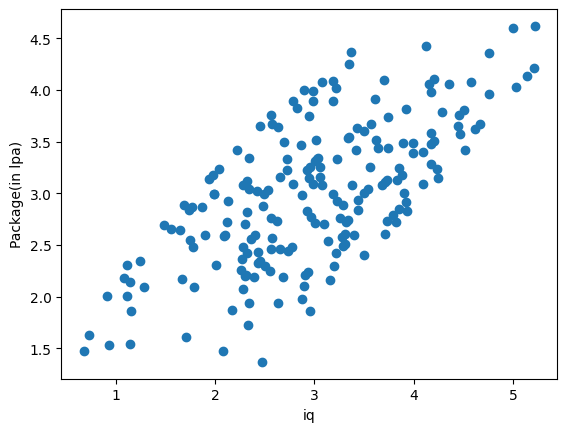

In [18]:
plt.scatter(new_df2['iq'],new_df2['package'])
plt.xlabel('iq')
plt.ylabel('Package(in lpa)')

In [19]:
np.random.randint(-100,100)

80

In [20]:
X = new_df2.iloc[:,0:2]
y = new_df2.iloc[:,-1]

In [21]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [22]:
lr = LinearRegression()
lr.fit(X_train,y_train)
y_pred = lr.predict(X_test)

In [24]:
print("r2 score:",r2_score(y_test,y_pred))
r2 = r2_score(y_test,y_pred)

r2 score: 0.8238514275961828


In [25]:
1 - ((1-r2)*(X_test.shape[0]-1)/(X_test.shape[0]-1-2))

0.8143298831419223